In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# How do the activity scores compare per each downsample to the total?

## Getting step 1 map csv from duck db. 

In [2]:
step1_map = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/step1_AD_AD_BC_RPTR_BC_designed.csv")
step1_map = step1_map[["AD", "AD_BC", "RPTR_BC"]]
step1_map

,AD,AD_BC,RPTR_BC
0,CCATTGTGTTCTCCTAAAGCTCCATCTGCTTTGATTACTCCAATGA...,AAAGTTATCAA,TTCGGTGCCATAAC
1,TTTGATCCATCTAATGAAATTTCATTTGATGATCCAGTCTTGTTTC...,CAGTAACTATC,ATACGACGCTTTAC
2,TCTTCTTCTGTTCCATCTTCTGTTTCTAATATGGGTACTGTTTCTC...,GACCCCAACGT,CACCACGCTTAGCT
3,CCAACTTCTACTGCTACTACTAATTTGGCTTCTCCATTGTCTTTGT...,GGATCCAAGTT,ATGCGTATTATTTA
4,GCTGCTCATTACTTCTTGGCTTTGAGACAATCTCAAGAGTTCTCTG...,TCACTTGTTAT,CGAATGACTCGACC
...,...,...,...
127403,ACTGCTTTGACTTCTCCATCTTTGTATGATGAATCTCCAGACTTTG...,CCTTCCCGCAG,TCGCAATTTCCTCT
127404,GTTGCTAATATGGCTGATTTAAATTCTAATAATTCATTTGATTCTG...,TTCACTCCTTA,CACGCAAGCCAAGG
127405,GCATTTACTAATTTGACTTCTCCATCTACTTATAATGAATCTCCAG...,CTCGGCAGAAG,TAACCCCAACACCG
127406,AATGCTTCTTCTGCTCCATCTTCTTCTTCATTTGGTTTGTCTGGTA...,TAAGAAACGAC,GAGGACAATCATCG


## Full results for time point 30

In [6]:
# Getting RT results alone
RPTR_BC_umi_counts_t30 = pd.read_csv("../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_1_chunk/RPTR_1_30_S5_R1_001_1_chunk.fq_simple_umi_counts.tsv", sep="\t")
RPTR_BC_umi_counts_t30 = RPTR_BC_umi_counts_t30.rename(columns={"count": "RT_umi_count"})

# Getting AD results alone
AD_BC_counts_t30 = pd.read_csv("../../output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_AD_1_30/AD_1_30_simple_umi_counts.tsv", sep="\t")
AD_BC_counts_t30 = AD_BC_counts_t30.rename(columns={"count": "AD_umi_count"})

# Adding RT results to step 1 map
step1_map_with_RPTR_BC_t30 = pd.merge(step1_map, RPTR_BC_umi_counts_t30, how="left")

# Adding AD results to step 1 map
step1_map_with_RPTR_BC_AD_BC_t30 = pd.merge(step1_map_with_RPTR_BC_t30, AD_BC_counts_t30, how="left")

# Removing nulls from step 1 map
step1_map_with_RPTR_BC_AD_BC_no_nulls_t30 = step1_map_with_RPTR_BC_AD_BC_t30.dropna()

# Adding '_full' suffix to the last two columns
step1_map_with_RPTR_BC_AD_BC_no_nulls_t30 = step1_map_with_RPTR_BC_AD_BC_no_nulls_t30.rename(
    columns={
        step1_map_with_RPTR_BC_AD_BC_no_nulls_t30.columns[-2]: step1_map_with_RPTR_BC_AD_BC_no_nulls_t30.columns[-2] + '_full',
        step1_map_with_RPTR_BC_AD_BC_no_nulls_t30.columns[-1]: step1_map_with_RPTR_BC_AD_BC_no_nulls_t30.columns[-1] + '_full'
    }
)

# Creating a copy and calculating activity
step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t30 = step1_map_with_RPTR_BC_AD_BC_no_nulls_t30.copy(deep=True)
step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t30["activity_full"] = (
    step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t30["RT_umi_count_full"].astype(int) /
    step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t30["AD_umi_count_full"].astype(int)
)

step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t30

,AD,AD_BC,RPTR_BC,RT_umi_count_full,AD_umi_count_full,activity_full
7,GATGATATTGTTGATGTTGTTGGTGATTCTCCATCTACTTCTCCAA...,CTCTGTTGCAG,TGGATACTAACCTG,315.0,1988.0,0.158451
19,ATGGGTACTGTTTCTCCACAAGATTTGTTGATTCAAGAACCATTTA...,AAGATATGTCT,TGCCTATGGTACAA,3864.0,594.0,6.505051
37,TCTGTTGAAGCTTCTCCAGCTACTCCATCTGAAGATTTGGAAGCTT...,TAATTCTTAAA,AAAGCAACCGAAGA,19.0,156.0,0.121795
42,AAATTGGAAGCTCCAGCTACTACTCATTTGACTTTGGATGCTATCT...,GGGTAGAAGTA,TAGTAGATGGAATT,32.0,31.0,1.032258
46,ATTGATATGTTCTTGGAAGATTCTGATTCTCCATCTGCTTCTTGTT...,CGATTCGAGAA,AACACAAACCATAG,39.0,160.0,0.243750
...,...,...,...,...,...,...
127373,GGTTCTGAAGAATGGGGTCCATTGTTTCCAGCTCAAGATGACTTCT...,TACAATTAACT,TTCGATTAGTTTCA,5057.0,886.0,5.707675
127378,ACTGCTGCTCCAAGATCTTCTGCTACTAAACATTCTACTGTTGCTG...,ACTAGTTTGCA,ACCCACGGCATTGT,83.0,528.0,0.157197
127379,CAATCTTCTGGTTTGAGATCTTCTTTGCAGAATCAAAGAGTTGCTG...,ACCCAGGACTT,TGGCTTTATGCAAT,86.0,462.0,0.186147
127388,GAATCTACTGTTTCTGTTGCTGCTACTGCTACTGTTACTGCTAAGA...,TAAGCCCTCGC,TACACTGATACTGA,227.0,1.0,227.000000


In [7]:
step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t30.to_csv("../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_1_chunk/step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t30.csv", index=False)

# Full results for time = 5

In [8]:
# Getting RT results alone
RPTR_BC_umi_counts_t5 = pd.read_csv("../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_1_chunk/RPTR_1_5_S2_R1_001_1_chunk.fq_simple_umi_counts.tsv", sep="\t", encoding='latin-1')
RPTR_BC_umi_counts_t5 = RPTR_BC_umi_counts_t5.rename(columns={"count": "RT_umi_count"})

# Getting AD results alone
AD_BC_counts_t5 = pd.read_csv("../../output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_AD_1_5/AD_1_5_simple_umi_counts.tsv", sep="\t")
AD_BC_counts_t5 = AD_BC_counts_t5.rename(columns={"count": "AD_umi_count"})

# Adding RT results to step 1 map
step1_map_with_RPTR_BC_t5 = pd.merge(step1_map, RPTR_BC_umi_counts_t5, how="left")

# Adding AD results to step 1 map
step1_map_with_RPTR_BC_AD_BC_t5 = pd.merge(step1_map_with_RPTR_BC_t5, AD_BC_counts_t5, how="left")

# Removing nulls from step 1 map
step1_map_with_RPTR_BC_AD_BC_no_nulls_t5 = step1_map_with_RPTR_BC_AD_BC_t5.dropna()

# Adding '_full' suffix to the last two columns
step1_map_with_RPTR_BC_AD_BC_no_nulls_t5 = step1_map_with_RPTR_BC_AD_BC_no_nulls_t5.rename(
    columns={
        step1_map_with_RPTR_BC_AD_BC_no_nulls_t5.columns[-2]: step1_map_with_RPTR_BC_AD_BC_no_nulls_t5.columns[-2] + '_full',
        step1_map_with_RPTR_BC_AD_BC_no_nulls_t5.columns[-1]: step1_map_with_RPTR_BC_AD_BC_no_nulls_t5.columns[-1] + '_full'
    }
)

# Creating a copy and calculating activity
step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t5 = step1_map_with_RPTR_BC_AD_BC_no_nulls_t5.copy(deep=True)
step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t5["activity_full"] = (
    step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t5["RT_umi_count_full"].astype(int) /
    step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t5["AD_umi_count_full"].astype(int)
)

step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t5

,AD,AD_BC,RPTR_BC,RT_umi_count_full,AD_umi_count_full,activity_full
7,GATGATATTGTTGATGTTGTTGGTGATTCTCCATCTACTTCTCCAA...,CTCTGTTGCAG,TGGATACTAACCTG,173.0,1891.0,0.091486
19,ATGGGTACTGTTTCTCCACAAGATTTGTTGATTCAAGAACCATTTA...,AAGATATGTCT,TGCCTATGGTACAA,765.0,542.0,1.411439
37,TCTGTTGAAGCTTCTCCAGCTACTCCATCTGAAGATTTGGAAGCTT...,TAATTCTTAAA,AAAGCAACCGAAGA,55.0,154.0,0.357143
42,AAATTGGAAGCTCCAGCTACTACTCATTTGACTTTGGATGCTATCT...,GGGTAGAAGTA,TAGTAGATGGAATT,37.0,22.0,1.681818
46,ATTGATATGTTCTTGGAAGATTCTGATTCTCCATCTGCTTCTTGTT...,CGATTCGAGAA,AACACAAACCATAG,32.0,101.0,0.316832
...,...,...,...,...,...,...
127373,GGTTCTGAAGAATGGGGTCCATTGTTTCCAGCTCAAGATGACTTCT...,TACAATTAACT,TTCGATTAGTTTCA,940.0,918.0,1.023965
127378,ACTGCTGCTCCAAGATCTTCTGCTACTAAACATTCTACTGTTGCTG...,ACTAGTTTGCA,ACCCACGGCATTGT,54.0,501.0,0.107784
127379,CAATCTTCTGGTTTGAGATCTTCTTTGCAGAATCAAAGAGTTGCTG...,ACCCAGGACTT,TGGCTTTATGCAAT,46.0,485.0,0.094845
127388,GAATCTACTGTTTCTGTTGCTGCTACTGCTACTGTTACTGCTAAGA...,TAAGCCCTCGC,TACACTGATACTGA,188.0,1.0,188.000000


In [9]:
step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t5.to_csv("../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_1_chunk/step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t5.csv", index=False)

# For each downsample, save the activity scores

In [11]:
import os
import warnings
warnings.filterwarnings('ignore')
import tqdm
# Define the base directory
base_dir = "../../output/GCN4/downsampling"

# Iterate through all folders in the base directory
for folder in tqdm.tqdm(os.listdir(base_dir)):
    folder_path = os.path.join(base_dir, folder)
    if os.path.isdir(folder_path) and "RPTR" in folder:
        # print(folder)
        # Process the RPTR_BC_umi_counts file
        umi_counts_path = next(
            (os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith("simple_umi_counts.tsv")),
            None
        )
        if umi_counts_path is None:
            continue
        RPTR_BC_umi_counts = pd.read_csv(umi_counts_path, sep="\t", encoding='latin-1')
        RPTR_BC_umi_counts = RPTR_BC_umi_counts.rename(columns={"count": "RT_umi_count"})

        # Merge with step1_map
        step1_map_with_RPTR_BC = pd.merge(step1_map, RPTR_BC_umi_counts, how="left")

        if "1_30" in folder:
            AD_BC_counts = AD_BC_counts_t30
        else:
            AD_BC_counts = AD_BC_counts_t5

        # Merge with AD_BC_counts
        step1_map_with_RPTR_BC_AD_BC = pd.merge(step1_map_with_RPTR_BC, AD_BC_counts, how="left")

        # Remove nulls
        step1_map_with_RPTR_BC_AD_BC_no_nulls = step1_map_with_RPTR_BC_AD_BC.dropna()

        step1_map_with_RPTR_BC_AD_BC_no_nulls = step1_map_with_RPTR_BC_AD_BC_no_nulls.rename(
            columns={step1_map_with_RPTR_BC_AD_BC_no_nulls.columns[-2]: step1_map_with_RPTR_BC_AD_BC_no_nulls.columns[-2] + '_downsampled',
                    step1_map_with_RPTR_BC_AD_BC_no_nulls.columns[-1]: step1_map_with_RPTR_BC_AD_BC_no_nulls.columns[-1] + '_downsampled'}
        )

        step1_map_with_RPTR_BC_AD_BC_no_nulls["activity_downsampled"] = step1_map_with_RPTR_BC_AD_BC_no_nulls["RT_umi_count_downsampled"].astype(int) / step1_map_with_RPTR_BC_AD_BC_no_nulls["AD_umi_count_downsampled"].astype(int)

        if "1_30" in folder:
            step1_map_with_RPTR_BC_AD_BC_no_nulls = pd.merge(
                step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t30,
                step1_map_with_RPTR_BC_AD_BC_no_nulls,
                on=["AD", "AD_BC", "RPTR_BC"],
                how="inner",
            )
        else:
            step1_map_with_RPTR_BC_AD_BC_no_nulls = pd.merge(
                step1_map_with_RPTR_BC_AD_BC_no_nulls_full_t5,
                step1_map_with_RPTR_BC_AD_BC_no_nulls,
                on=["AD", "AD_BC", "RPTR_BC"],
                how="inner",
            )

        # Save the processed file as a CSV
        output_path = os.path.join(folder_path, "processed_step1_map.csv")
        step1_map_with_RPTR_BC_AD_BC_no_nulls.to_csv(output_path, index=False)
        #print(f"Processed file saved to: {output_path}")

100%|██████████| 251/251 [01:55<00:00,  2.17it/s]


# Calculating correlations of each downsample with full

In [116]:
import pandas as pd
import os
from scipy.stats import pearsonr, spearmanr

# Initialize an empty list to store correlation results
correlation_results = []

# Loop through the base directory
for folder in tqdm.tqdm(os.listdir(base_dir)):
    folder_path = os.path.join(base_dir, folder)
    if os.path.isdir(folder_path) and "RPTR" in folder:
        processed_file_path = os.path.join(folder_path, "processed_step1_map.csv")
        if os.path.exists(processed_file_path):
            # Read the processed_step1_map.csv file
            df = pd.read_csv(processed_file_path)
            
            # Check if the required columns exist
            if "activity_full" in df.columns and "activity_downsampled" in df.columns:
                # Calculate Pearson and Spearman correlations
                pearson_corr, _ = pearsonr(df["activity_full"], df["activity_downsampled"])
                spearman_corr, _ = spearmanr(df["activity_full"], df["activity_downsampled"])
                
                # Append the results to the list
                correlation_results.append({
                    "folder_path": folder_path,
                    "pearson_corr": pearson_corr,
                    "spearman_corr": spearman_corr,
                    "num_rows": len(df)  # Track the number of rows
                })

                # Create scatterplot
                fig, ax = plt.subplots(figsize=(6,6), dpi=300)
                sns.set_context('talk')
                ax.scatter(df["activity_full"], df["activity_downsampled"], alpha=0.5, edgecolor = 'none', s = 5)
                ax.set_xscale('log')
                ax.set_yscale('log')
                ax.set_xlabel("Activity Full")
                ax.set_ylabel("Activity Downsampled")
                ax.set_title("Activity Full vs Activity Downsampled")
                ax.grid(False)
                sns.despine(ax=ax)

                # Add correlations as text
                ax.text(0.05, 0.95,
                        f"Pearson: {pearson_corr:.2f}\nSpearman: {spearman_corr:.2f}",
                        transform=ax.transAxes, fontsize=12, verticalalignment='top')

                # Save figure
                scatterplot_path = os.path.join(folder_path, "activity_scatterplot.png")
                plt.savefig(scatterplot_path, bbox_inches='tight')
                plt.close(fig)

# Convert the results into a DataFrame
correlation_df = pd.DataFrame(correlation_results)

# Display the correlation DataFrame
correlation_df

100%|██████████| 251/251 [02:37<00:00,  1.59it/s]


,folder_path,pearson_corr,spearman_corr,num_rows
0,../../output/GCN4/downsampling/trebl_experimen...,0.999500,0.989250,14052
1,../../output/GCN4/downsampling/trebl_experimen...,0.999769,0.989749,13986
2,../../output/GCN4/downsampling/trebl_experimen...,0.999352,0.982615,13763
3,../../output/GCN4/downsampling/trebl_experimen...,0.999739,0.994606,14210
4,../../output/GCN4/downsampling/trebl_experimen...,0.999741,0.994896,14210
...,...,...,...,...
135,../../output/GCN4/downsampling/trebl_experimen...,0.999747,0.994816,14214
136,../../output/GCN4/downsampling/trebl_experimen...,0.999909,0.996901,14274
137,../../output/GCN4/downsampling/trebl_experimen...,0.999860,0.991066,14019
138,../../output/GCN4/downsampling/trebl_experimen...,0.999648,0.988707,13967


In [13]:
correlation_df['num_splits'] = correlation_df['folder_path'].str.extract(r'_(\d+)_chunks')#.astype(int)

correlation_df.loc[correlation_df['folder_path'].str.contains('_75'), 'num_splits'] = 4 / 3
correlation_df.loc[correlation_df['folder_path'].str.contains('_1_chunk'), 'num_splits'] = 1

correlation_df
#[correlation_df["num_splits"].isna()]["folder_path"]

,folder_path,pearson_corr,spearman_corr,num_rows,num_splits
0,../../output/GCN4/downsampling/trebl_experimen...,0.999500,0.989250,14052,50
1,../../output/GCN4/downsampling/trebl_experimen...,0.999769,0.989749,13986,8
2,../../output/GCN4/downsampling/trebl_experimen...,0.999352,0.982615,13763,100
3,../../output/GCN4/downsampling/trebl_experimen...,0.999739,0.994606,14210,20
4,../../output/GCN4/downsampling/trebl_experimen...,0.999741,0.994896,14210,20
...,...,...,...,...,...
135,../../output/GCN4/downsampling/trebl_experimen...,0.999747,0.994816,14214,20
136,../../output/GCN4/downsampling/trebl_experimen...,0.999909,0.996901,14274,8
137,../../output/GCN4/downsampling/trebl_experimen...,0.999860,0.991066,14019,5
138,../../output/GCN4/downsampling/trebl_experimen...,0.999648,0.988707,13967,10


In [14]:
correlation_df["percent_reads"] = 100 / correlation_df["num_splits"].astype(float)
correlation_df["time"] = correlation_df["folder_path"].str.extract("RPTR_1_(\d+)_").astype(int)
correlation_df

,folder_path,pearson_corr,spearman_corr,num_rows,num_splits,percent_reads,time
0,../../output/GCN4/downsampling/trebl_experimen...,0.999500,0.989250,14052,50,2.0,30
1,../../output/GCN4/downsampling/trebl_experimen...,0.999769,0.989749,13986,8,12.5,5
2,../../output/GCN4/downsampling/trebl_experimen...,0.999352,0.982615,13763,100,1.0,30
3,../../output/GCN4/downsampling/trebl_experimen...,0.999739,0.994606,14210,20,5.0,30
4,../../output/GCN4/downsampling/trebl_experimen...,0.999741,0.994896,14210,20,5.0,30
...,...,...,...,...,...,...,...
135,../../output/GCN4/downsampling/trebl_experimen...,0.999747,0.994816,14214,20,5.0,30
136,../../output/GCN4/downsampling/trebl_experimen...,0.999909,0.996901,14274,8,12.5,30
137,../../output/GCN4/downsampling/trebl_experimen...,0.999860,0.991066,14019,5,20.0,5
138,../../output/GCN4/downsampling/trebl_experimen...,0.999648,0.988707,13967,10,10.0,5


In [15]:
correlation_df.sort_values(by = 'pearson_corr')

,folder_path,pearson_corr,spearman_corr,num_rows,num_splits,percent_reads,time
39,../../output/GCN4/downsampling/trebl_experimen...,0.998900,0.964735,13442,200,0.5,5
107,../../output/GCN4/downsampling/trebl_experimen...,0.998905,0.965214,13431,200,0.5,5
98,../../output/GCN4/downsampling/trebl_experimen...,0.998973,0.963584,13428,200,0.5,5
114,../../output/GCN4/downsampling/trebl_experimen...,0.998977,0.963961,13456,200,0.5,5
6,../../output/GCN4/downsampling/trebl_experimen...,0.999010,0.964306,13437,200,0.5,5
...,...,...,...,...,...,...,...
63,../../output/GCN4/downsampling/trebl_experimen...,0.999991,0.998895,14347,1.333333,75.0,30
48,../../output/GCN4/downsampling/trebl_experimen...,0.999996,0.998831,14341,2,50.0,30
45,../../output/GCN4/downsampling/trebl_experimen...,0.999996,0.998877,14347,2,50.0,30
103,../../output/GCN4/downsampling/trebl_experimen...,1.000000,1.000000,14114,1,100.0,5


In [16]:
correlation_df.to_csv("../../output/GCN4_downsampling_correlation_results.csv", index=False)

In [17]:
# Filter data for time = 5 and time = 30
correlation_df_5 = correlation_df[correlation_df["time"] == 5]
correlation_df_30 = correlation_df[correlation_df["time"] == 30]


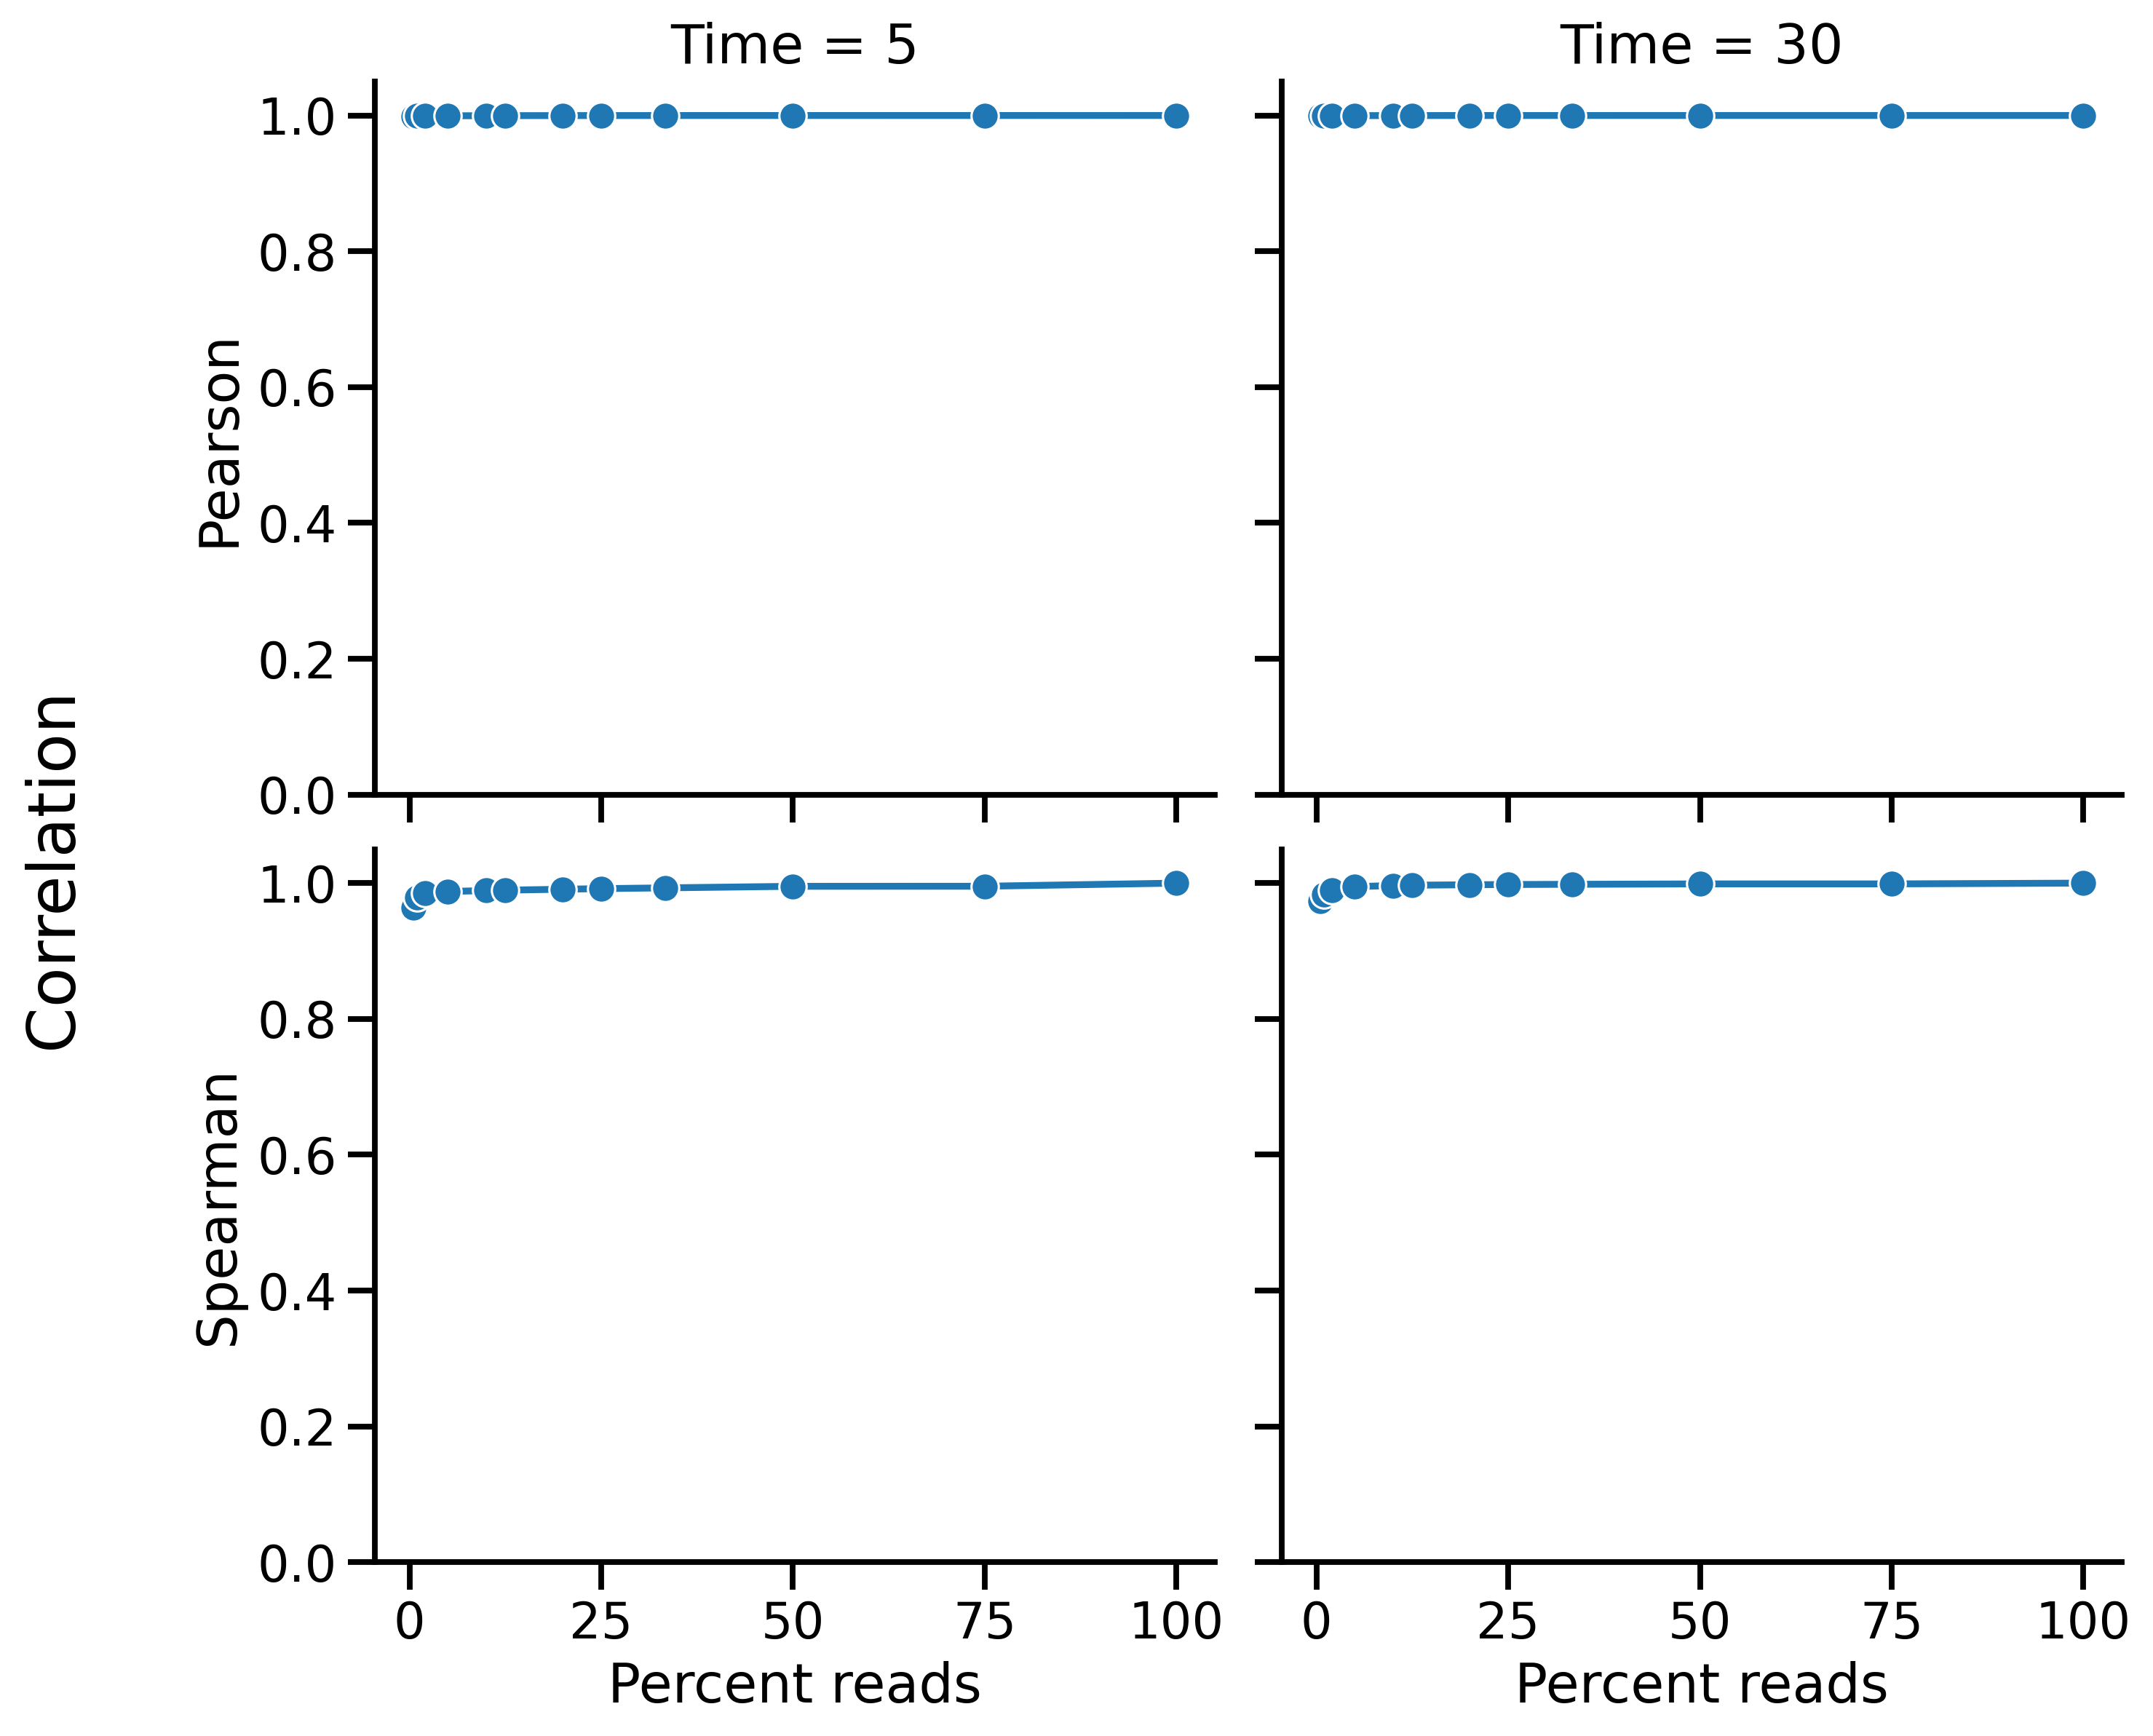

In [28]:
fig, axes = plt.subplots(
    2, 2, figsize=(10,8), dpi=300, sharex=True, sharey='row'
)
sns.set_context("talk")

# ---------- Pearson (row 0) ----------
sns.lineplot(
    data=correlation_df_5,
    x="percent_reads",
    y="pearson_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Time = 5")
axes[0, 0].set_ylabel("Pearson")
axes[0, 0].set_xlabel("")
sns.despine(ax=axes[0, 0])

sns.lineplot(
    data=correlation_df_30,
    x="percent_reads",
    y="pearson_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Time = 30")
axes[0, 1].set_ylabel("")
axes[0, 1].set_xlabel("")
sns.despine(ax=axes[0, 1])

# ---------- Spearman (row 1) ----------
sns.lineplot(
    data=correlation_df_5,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[1, 0]
)
axes[1, 0].set_ylabel("Spearman")
axes[1, 0].set_xlabel("Percent reads")
sns.despine(ax=axes[1, 0])

sns.lineplot(
    data=correlation_df_30,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[1, 1]
)
axes[1, 1].set_ylabel("")
axes[1, 1].set_xlabel("Percent reads")
sns.despine(ax=axes[1, 1])
fig.align_ylabels(axes)
fig.supylabel("Correlation")
plt.tight_layout(pad = 0.5)

for ax in axes.flatten():
    ax.set_ylim(0,1.05)
    
plt.show()

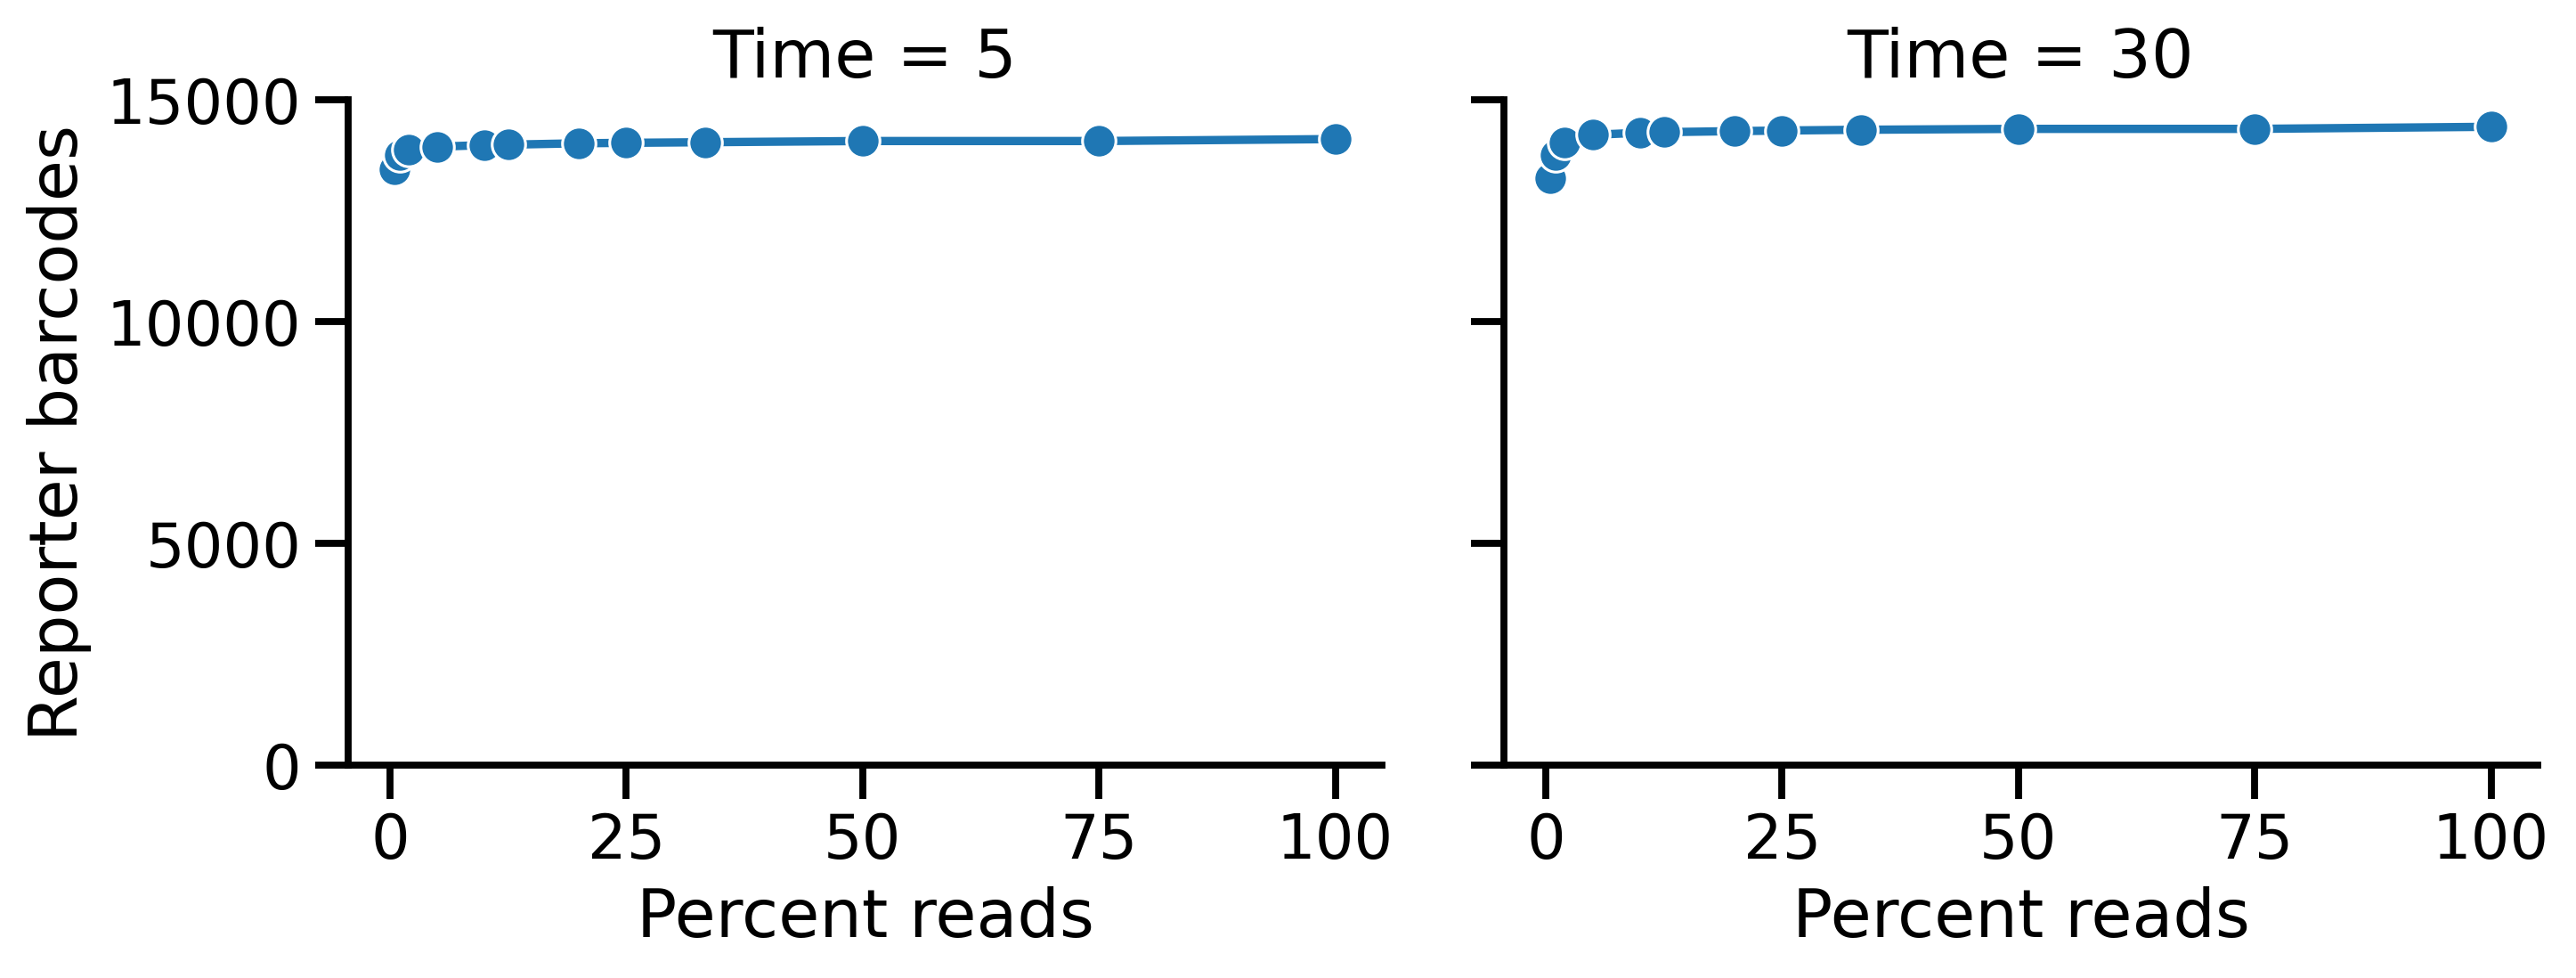

In [34]:
# Create subplots
fig, axes = plt.subplots(
    1, 2,
    figsize=(10,4),
    dpi=300,
    sharey=True
)
sns.set_context("talk")

# ---------- Time = 5 ----------
sns.lineplot(
    data=correlation_df_5,
    x="percent_reads",
    y="num_rows",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[0]
)
axes[0].set_title("Time = 5")
axes[0].set_ylabel("Reporter barcodes")
axes[0].set_xlabel("Percent reads")
sns.despine(ax=axes[0])

# ---------- Time = 30 ----------
sns.lineplot(
    data=correlation_df_30,
    x="percent_reads",
    y="num_rows",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Time = 30")
axes[1].set_ylabel("")
axes[1].set_xlabel("Percent reads")
sns.despine(ax=axes[1])

for ax in axes.flatten():
    ax.set_ylim(0,15000)
    
plt.tight_layout()
plt.show()

# Reads per UMI for each downsample?

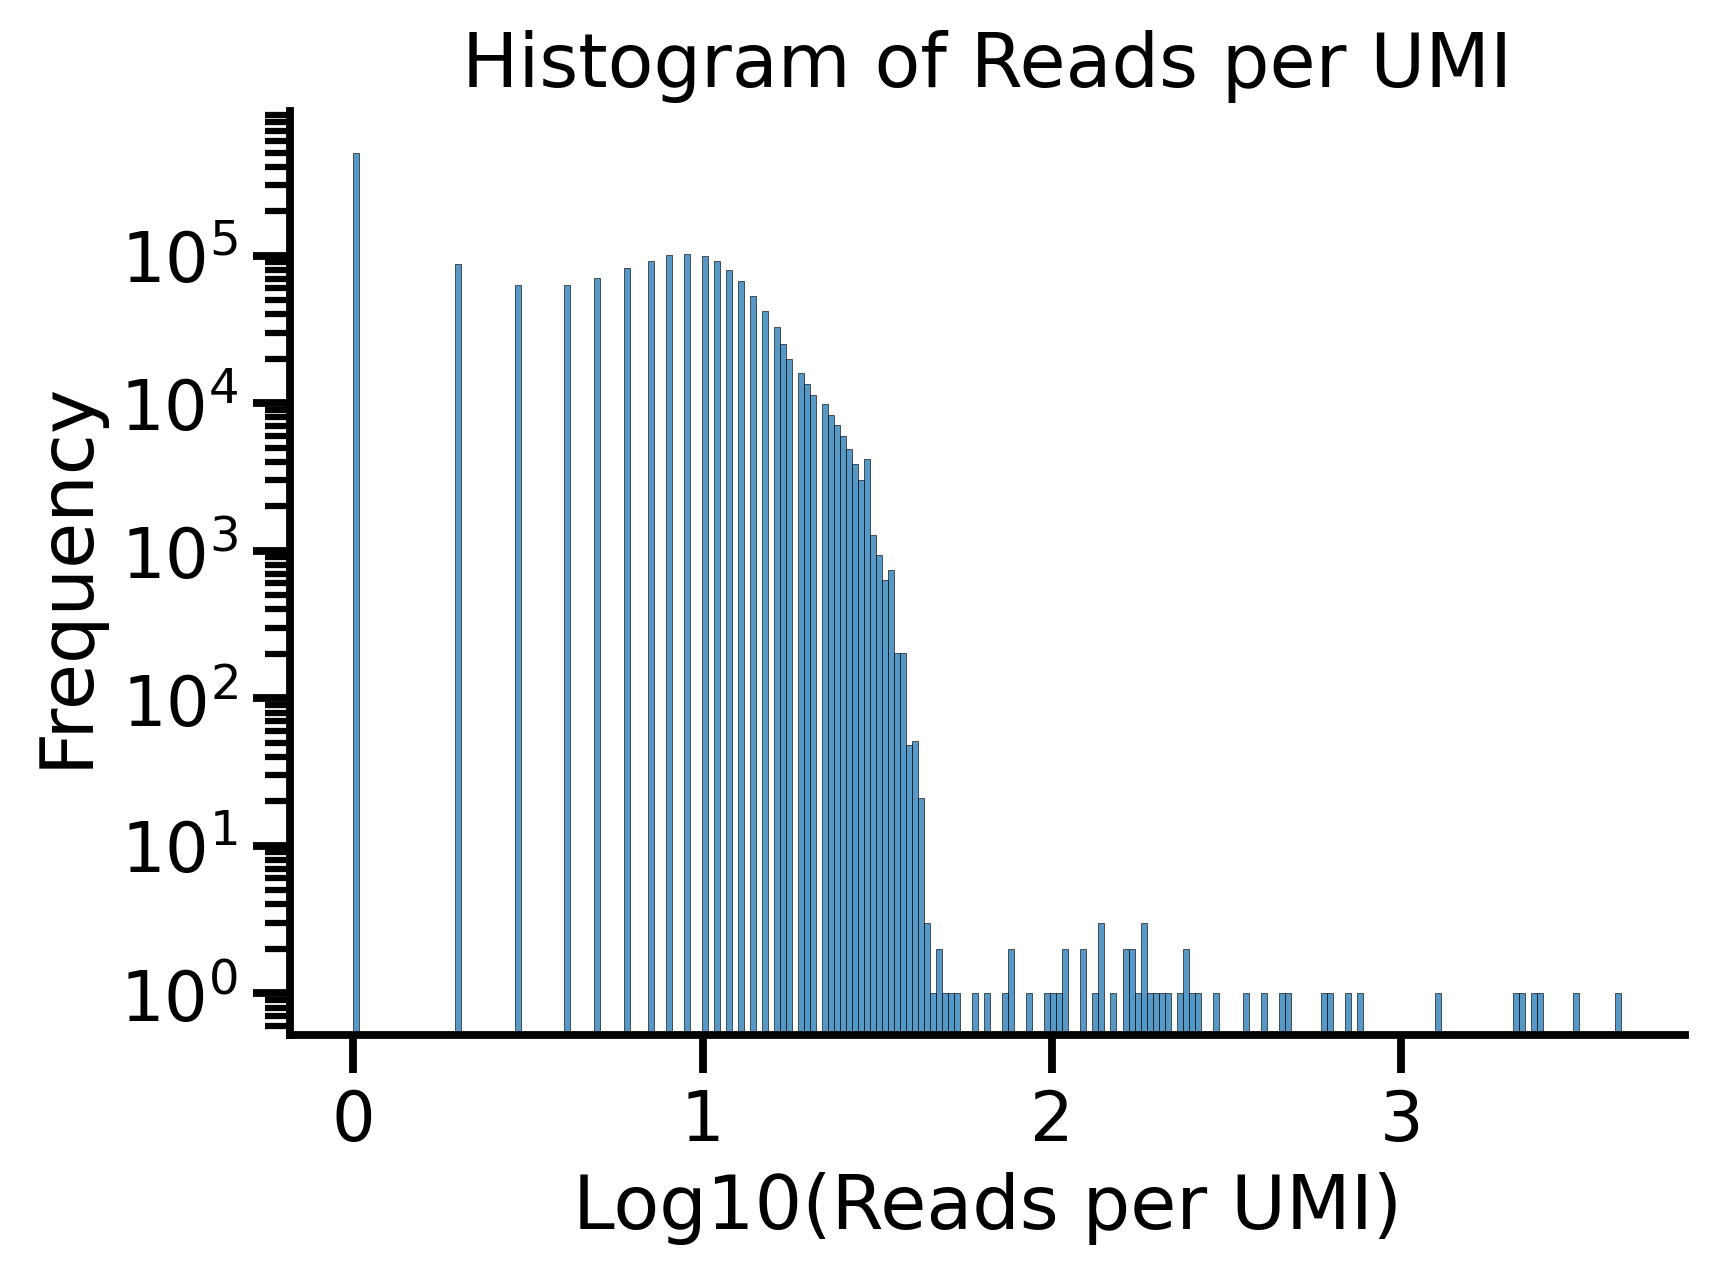

In [37]:
# Read the reads_per_umi file
reads_per_umi_df = pd.read_csv("../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_20_chunks_part_1/RPTR_1_5_S2_R1_001_20_chunks_part_1.fq_reads_per_umi.tsv", sep="\t")

import numpy as np

# Plot the histogram
plt.figure(figsize=(6, 4), dpi=300)
sns.set_context('talk')
ax = sns.histplot(np.log10(reads_per_umi_df['reads']))
ax.set_yscale('log')
plt.title("Histogram of Reads per UMI")
plt.xlabel("Log10(Reads per UMI)")
plt.ylabel("Frequency")
sns.despine()

# Save the histogram in the folder
plt.show()

## 30 min

In [118]:
from pathlib import Path

# Folder containing all RPTR chunks
folder = Path("../../output/GCN4/downsampling/")
chunk_files_t5 = sorted(folder.glob("*RPTR*1_30*chunks_part_1/*_part_1.fq_reads_per_umi.tsv"))

def get_num_chunks(path):
    # match the last number before "_chunks_part_1"
    m = re.search(r"_(\d+)_chunks_part_1", path.name)
    if m:
        return int(m.group(1))
    else:
        return float('inf')  # push non-matching files to the end

chunk_files_t5 = sorted(chunk_files_t5, key=get_num_chunks)

# Check order
for p in chunk_files_t5:
    print(p.name)

RPTR_1_30_S5_R1_001_2_chunks_part_1.fq_reads_per_umi.tsv
RPTR_1_30_S5_R1_001_3_chunks_part_1.fq_reads_per_umi.tsv
RPTR_1_30_S5_R1_001_4_chunks_part_1.fq_reads_per_umi.tsv
RPTR_1_30_S5_R1_001_5_chunks_part_1.fq_reads_per_umi.tsv
RPTR_1_30_S5_R1_001_8_chunks_part_1.fq_reads_per_umi.tsv
RPTR_1_30_S5_R1_001_10_chunks_part_1.fq_reads_per_umi.tsv
RPTR_1_30_S5_R1_001_20_chunks_part_1.fq_reads_per_umi.tsv
RPTR_1_30_S5_R1_001_50_chunks_part_1.fq_reads_per_umi.tsv
RPTR_1_30_S5_R1_001_100_chunks_part_1.fq_reads_per_umi.tsv
RPTR_1_30_S5_R1_001_200_chunks_part_1.fq_reads_per_umi.tsv


In [108]:
np.round(110 / 3, 1)

36.7

../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_2_chunks_part_1/RPTR_1_30_S5_R1_001_2_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_3_chunks_part_1/RPTR_1_30_S5_R1_001_3_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_4_chunks_part_1/RPTR_1_30_S5_R1_001_4_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_5_chunks_part_1/RPTR_1_30_S5_R1_001_5_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_8_chunks_part_1/RPTR_1_30_S5_R1_001_8_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_10_chunks_part_1/RPTR_1_30_S5_R1_001_10_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_ye

<Figure size 1920x1440 with 0 Axes>

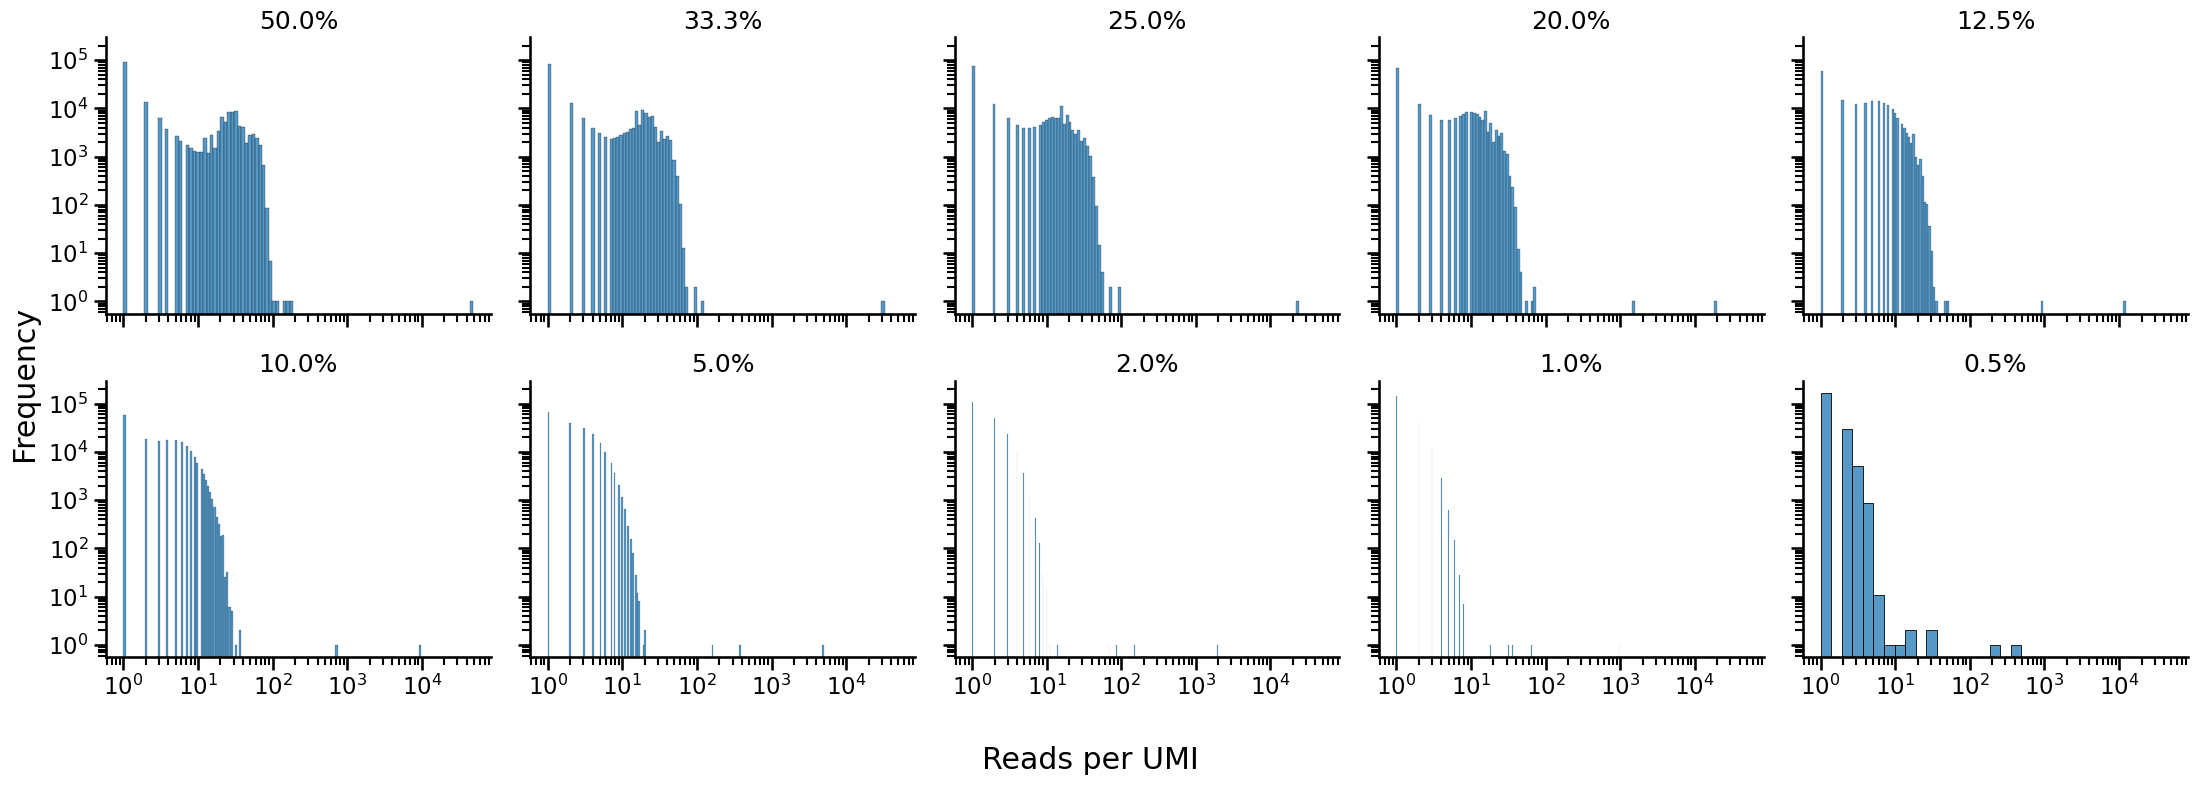

In [111]:
# Setup figure: one row, multiple columns (adjust figsize)
sns.set_context('talk')
plt.figure(dpi = 300)
n_chunks = int(len(chunk_files_t5) / 2)
fig, axes = plt.subplots(2, n_chunks, figsize=(4.5*n_chunks, 8), sharey=True, sharex = True)

if n_chunks == 1:
    axes = [axes]  # make it iterable if only one subplot

sns.set_context('talk')

for ax, path in zip(axes.flatten(), chunk_files_t5):
    print(path)

    # Plot histogram
    df = pd.read_csv(path, sep="\t", engine='python', nrows = 200000)
    sns.histplot(df['reads'], log_scale = (True, True), ax=ax)
    #ax.set_yscale('log')

    # Title
    num_chunks = int(re.search('(\d+)_chunks', str(path)).group(1))
    ax.set_title(f"{np.round(100 / num_chunks, 1)}%", fontsize='medium')

    # Formatting
    ax.set_xlabel("Log10(Reads per UMI)")
    ax.set_ylabel("Frequency")
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine(ax=ax)
    
fig.supxlabel("Reads per UMI")
fig.supylabel("Frequency")
plt.tight_layout()
plt.show()

## 5 min

In [121]:
folder = Path("../../output/GCN4/downsampling/")
chunk_files_t5 = sorted(folder.glob("*RPTR_1_5_*chunks_part_1/*_part_1.fq_reads_per_umi.tsv"))
chunk_files_t5 = sorted(chunk_files_t5, key=get_num_chunks)
# Check order
for p in chunk_files_t5:
    print(p.name)

RPTR_1_5_S2_R1_001_2_chunks_part_1.fq_reads_per_umi.tsv
RPTR_1_5_S2_R1_001_3_chunks_part_1.fq_reads_per_umi.tsv
RPTR_1_5_S2_R1_001_4_chunks_part_1.fq_reads_per_umi.tsv
RPTR_1_5_S2_R1_001_5_chunks_part_1.fq_reads_per_umi.tsv
RPTR_1_5_S2_R1_001_8_chunks_part_1.fq_reads_per_umi.tsv
RPTR_1_5_S2_R1_001_10_chunks_part_1.fq_reads_per_umi.tsv
RPTR_1_5_S2_R1_001_20_chunks_part_1.fq_reads_per_umi.tsv
RPTR_1_5_S2_R1_001_50_chunks_part_1.fq_reads_per_umi.tsv
RPTR_1_5_S2_R1_001_100_chunks_part_1.fq_reads_per_umi.tsv
RPTR_1_5_S2_R1_001_200_chunks_part_1.fq_reads_per_umi.tsv


../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_2_chunks_part_1/RPTR_1_5_S2_R1_001_2_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_3_chunks_part_1/RPTR_1_5_S2_R1_001_3_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_4_chunks_part_1/RPTR_1_5_S2_R1_001_4_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_5_chunks_part_1/RPTR_1_5_S2_R1_001_5_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_8_chunks_part_1/RPTR_1_5_S2_R1_001_8_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_10_chunks_part_1/RPTR_1_5_S2_R1_001_10_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_u

<Figure size 1920x1440 with 0 Axes>

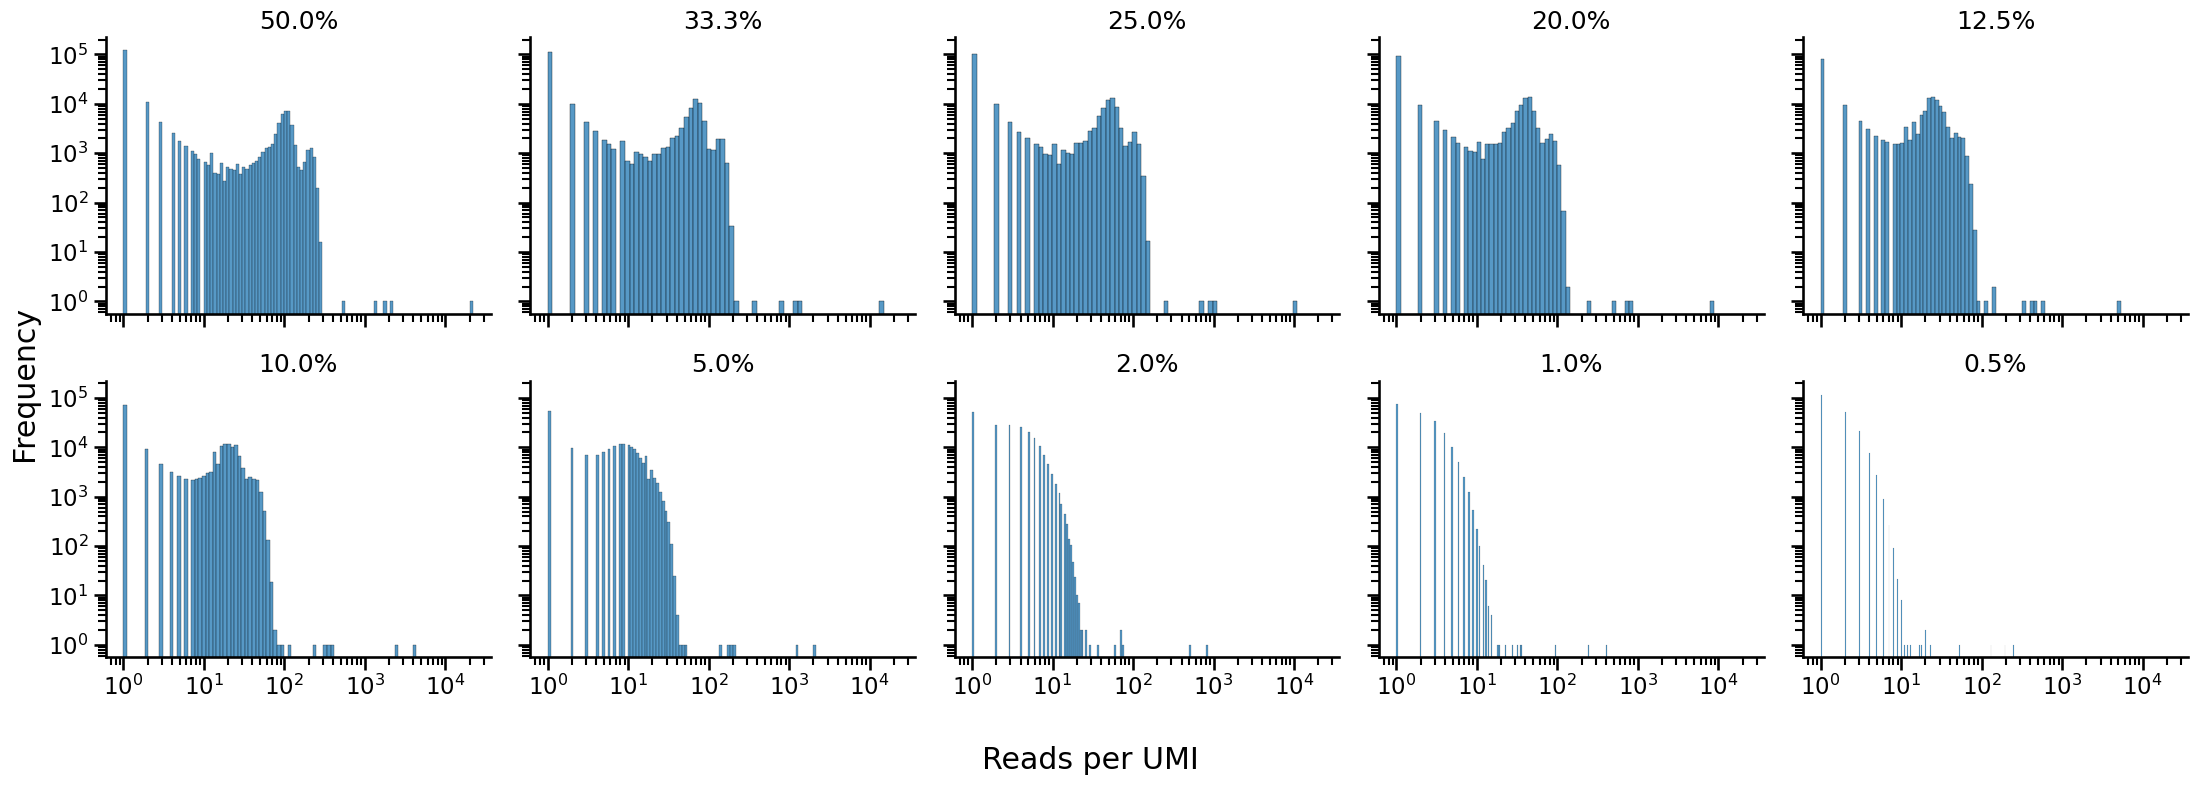

In [122]:
# Setup figure: one row, multiple columns (adjust figsize)
sns.set_context('talk')
plt.figure(dpi = 300)
n_chunks = int(len(chunk_files_t5) / 2)
fig, axes = plt.subplots(2, n_chunks, figsize=(4.5*n_chunks, 8), sharey=True, sharex = True)

if n_chunks == 1:
    axes = [axes]  # make it iterable if only one subplot

sns.set_context('talk')

for ax, path in zip(axes.flatten(), chunk_files_t5):
    print(path)

    # Plot histogram
    df = pd.read_csv(path, sep="\t", engine='python', nrows = 200000)
    sns.histplot(df['reads'], log_scale = (True, True), ax=ax)
    #ax.set_yscale('log')

    # Title
    num_chunks = int(re.search('(\d+)_chunks', str(path)).group(1))
    ax.set_title(f"{np.round(100 / num_chunks, 1)}%", fontsize='medium')

    # Formatting
    ax.set_xlabel("Log10(Reads per UMI)")
    ax.set_ylabel("Frequency")
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine(ax=ax)
    
fig.supxlabel("Reads per UMI")
fig.supylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
# from concurrent.futures import ThreadPoolExecutor
# import pandas as pd
# import os
# import tqdm
# import seaborn as sns

# import matplotlib.pyplot as plt

# base_dir = "../../output/GCN4/downsampling/"

# def process_folder(folder):
#     folder_path = os.path.join(base_dir, folder)
#     if os.path.isdir(folder_path):
#         # Find the reads_per_umi file
#         reads_per_umi_path = next(
#             (os.path.join(folder_path, file) for file in os.listdir(folder_path) if "reads_per_umi" in file and "20_chunks" in file),
#             None
#         )
#         if reads_per_umi_path is None:
#             return
        
#         # Read the reads_per_umi file
#         reads_per_umi_df = pd.read_csv(reads_per_umi_path, sep="\t")
        
#         # Plot the histogram
#         plt.figure(figsize=(6, 4), dpi=300)
#         sns.set_context('talk')
#         sns.histplot(reads_per_umi_df['reads'], kde=False, log_scale=(True, True), bins = 100)
#         plt.title("Histogram of Reads per UMI")
#         plt.xlabel("Reads per UMI")
#         plt.ylabel("Frequency")
#         plt.grid(False)
#         sns.despine()
        
#         # Save the histogram in the folder
#         hist_path = os.path.join(folder_path, "reads_per_umi_histogram.png")
#         plt.savefig(hist_path, bbox_inches='tight')
#         plt.show()

# # Get the list of folders
# folders = [folder for folder in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, folder))]

# # Use ThreadPoolExecutor to parallelize the processing
# with ThreadPoolExecutor() as executor:
#     list(tqdm.tqdm(executor.map(process_folder, folders), total=len(folders)))